In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
CSV_FOLDER = Path(r"C:\Users\david\Desktop\Results\datos_csv") 

csv_files = sorted(list(CSV_FOLDER.glob('*.csv')))[:8]

⚠️ ERROR en flat_pinpoint_103_landmarks.csv: No encuentro la columna 'right_ankle_y'.
Las columnas disponibles son: ['frame_id', 'NOSE_x', 'NOSE_y', 'NOSE_z', 'NOSE_v', 'LEFT_EYE_INNER_x', 'LEFT_EYE_INNER_y', 'LEFT_EYE_INNER_z', 'LEFT_EYE_INNER_v', 'LEFT_EYE_x', 'LEFT_EYE_y', 'LEFT_EYE_z', 'LEFT_EYE_v', 'LEFT_EYE_OUTER_x', 'LEFT_EYE_OUTER_y', 'LEFT_EYE_OUTER_z', 'LEFT_EYE_OUTER_v', 'RIGHT_EYE_INNER_x', 'RIGHT_EYE_INNER_y', 'RIGHT_EYE_INNER_z', 'RIGHT_EYE_INNER_v', 'RIGHT_EYE_x', 'RIGHT_EYE_y', 'RIGHT_EYE_z', 'RIGHT_EYE_v', 'RIGHT_EYE_OUTER_x', 'RIGHT_EYE_OUTER_y', 'RIGHT_EYE_OUTER_z', 'RIGHT_EYE_OUTER_v', 'LEFT_EAR_x', 'LEFT_EAR_y', 'LEFT_EAR_z', 'LEFT_EAR_v', 'RIGHT_EAR_x', 'RIGHT_EAR_y', 'RIGHT_EAR_z', 'RIGHT_EAR_v', 'MOUTH_LEFT_x', 'MOUTH_LEFT_y', 'MOUTH_LEFT_z', 'MOUTH_LEFT_v', 'MOUTH_RIGHT_x', 'MOUTH_RIGHT_y', 'MOUTH_RIGHT_z', 'MOUTH_RIGHT_v', 'LEFT_SHOULDER_x', 'LEFT_SHOULDER_y', 'LEFT_SHOULDER_z', 'LEFT_SHOULDER_v', 'RIGHT_SHOULDER_x', 'RIGHT_SHOULDER_y', 'RIGHT_SHOULDER_z', 'RI

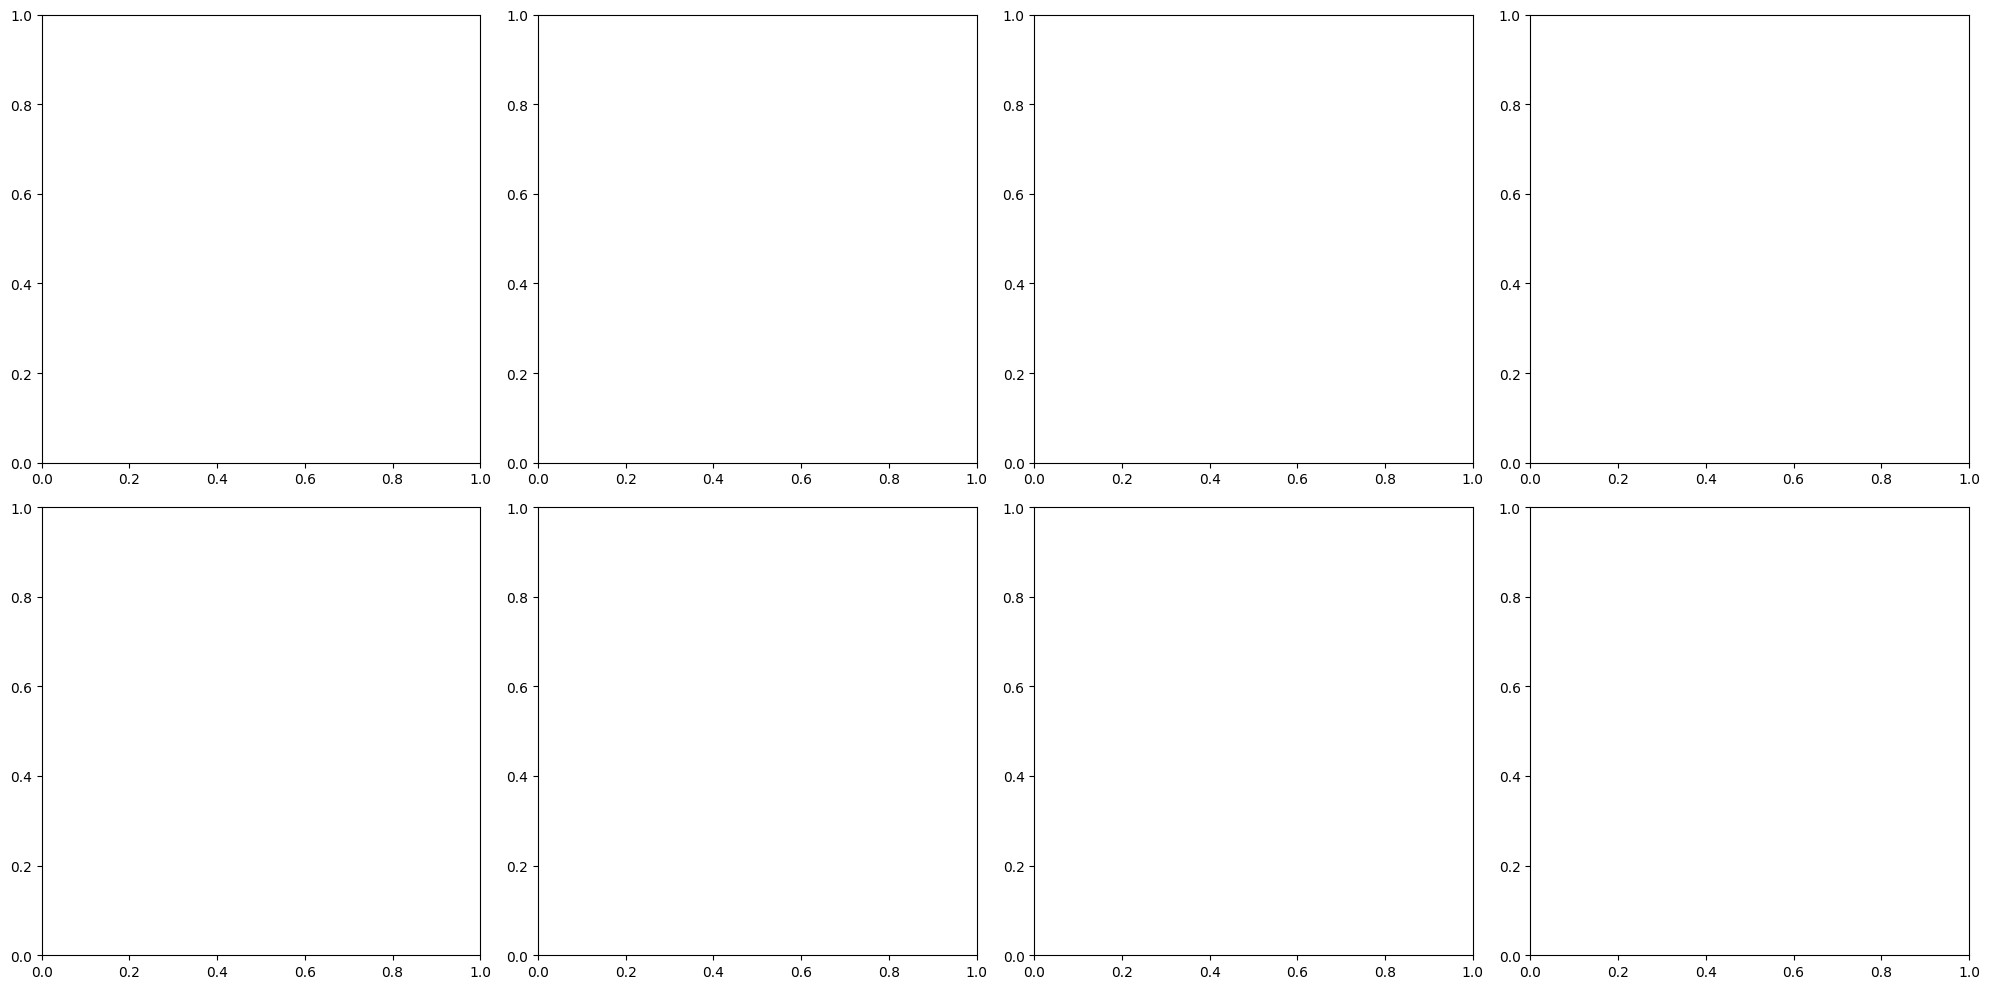

In [3]:
# ... (Tus imports y la definición de csv_files que ya tienes arriba) ...

# 1. CONFIGURACIÓN
# IMPORTANTE: Cambia esto por el nombre EXACTO de la columna en tu CSV
# Puede ser 'right_ankle_y', 'y_28', 'RAnkle_y', etc.
COLUMNA_TOBILLO = 'right_ankle_y' 

# Preparamos una figura grande para ver los 8 gráficos (2 filas x 4 columnas)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente (0 a 7)

for i, archivo in enumerate(csv_files):
    if i >= 8: break # Por seguridad, aunque ya has filtrado [:8]
    
    # Cargar datos
    df = pd.read_csv(archivo)
    
    # --- BLOQUE DE SEGURIDAD (Por si no sabes el nombre de la columna) ---
    if COLUMNA_TOBILLO not in df.columns:
        print(f"⚠️ ERROR en {archivo.name}: No encuentro la columna '{COLUMNA_TOBILLO}'.")
        print(f"Las columnas disponibles son: {list(df.columns)}")
        continue
    # ---------------------------------------------------------------------

    data_y = df[COLUMNA_TOBILLO]
    frames = df.index # Asumimos que cada fila es un frame

    # Calcular el "Frame Buscado" (la mitad)
    frame_mitad = len(df) // 2
    valor_mitad = data_y.iloc[frame_mitad]

    # Plotear en su hueco correspondiente
    ax = axes[i]
    ax.plot(frames, data_y, label='Desplazamiento', color='blue', alpha=0.7)
    
    # Pintar el PUNTO ROJO en la mitad
    ax.scatter(frame_mitad, valor_mitad, color='red', s=100, zorder=5, label=f'Frame {frame_mitad}')
    
    # Decoración
    ax.set_title(f"Video: {archivo.name}", fontsize=10)
    ax.set_xlabel("Frames")
    ax.set_ylabel("Posición Y (Tobillo Der.)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()